# Logistic Regression
## Theory
Suppose we have $n$ features and $m$ training points $(\mathbf{x}_1,y_1),\cdots, (\mathbf{x}_m,y_m)$, where each $\mathbf{x}_i$ is an $n$-dimensional column vector, and each $y_i \in \{0,1\}$ ($0,1$ represent two categories). Then, if we want to predict the category to which $y_{m+l}$ belongs to, given any $\mathbf{x}_{m+l}$, we use logistic regression to do so. \
Our hypothesis funciton is $h_\theta (\mathbf{x}) = \dfrac{1}{1+e^{-\theta^T \mathbf{x}}}$, where $\theta$ is the column vector $(\theta_1,\cdots,\theta_n)^T$

Now, we assume that $h_\theta(\mathbf{x})$ gives us the expectated value of $y$ for that specific $\mathbf{x}$. Thus, $y_i \sim \text{Bern}(h_\theta(\mathbf{x}_i))$, with respect to the probability measure $\mathbb{P}(\cdot  | \mathbf{x}_i ; \theta)$. So, 
$$\mathbb{P}(y_i = 1| \mathbf{x_i};\theta) = h_\theta(\mathbf{x}_i)$$
$$\mathbb{P}(y_i = 0| \mathbf{x_i};\theta) = 1 - h_\theta(\mathbf{x}_i)$$
Which can be compactly written as:
$$\mathbb{P}(y_i | \mathbf{x_i};\theta) = (h_\theta(\mathbf{x}_i))^{y_i}(1-h_\theta(\mathbf{x}_i))^{1-y_i}$$

The likelihood function is defined by $L(\theta) = \mathbb{P}(\mathbf{y} | X ; \theta)$. Here $X = (\mathbf{x}_1^T,\cdots,\mathbf{x}_m^T)^T$ and $\mathbf{y} = (y_1,\cdots, y_m)$. Due to (assumed) independence of each observation pair, 

\begin{align}
L(\theta) &= \prod_{i=1}^m \mathbb{P}(y_i | \mathbf{x}_i ; \theta) \\
&= \prod_{i=1}^m (h_\theta(\mathbf{x}_i))^{y_i}(1-h_\theta(\mathbf{x}_i))^{1-y_i}
\end{align}
Our goal is to find the $\theta$ that maximizes $L$, which can also be done by maximizing an increasing function of $L$, $\ln L(\theta) = l(\theta)$
$$l(\theta) = \sum_{i=1}^m y_i \ln(h_\theta(\mathbf{x}_i)) + (1-y_i)\ln(1-h_\theta(\mathbf{x}_i))$$
This maximizing can be done via Gradient Ascent. \
After some calculations, we find gradient of $l(\theta)$ w.r.t. $\theta_j$ to be:
$$\frac{\partial l(\theta)}{\partial \theta_j} = \sum_{i=1}^m (y_i - h_\theta(\mathbf{x}_i))(\mathbf{x}_i)_j$$
Where $(\mathbf{x}_i)_j$ is the $j$-th coordinate of $\mathbf{x}_i$

Thus, our rule (for batch gradient ascent) is 
$$\theta_{j+1} = \theta_j + \alpha \left(\sum_{i=1}^m (y_i - h_\theta(\mathbf{x}_i))(\mathbf{x}_i)_j\right)$$
and the rule for stochastic gradient ascent is 
$$\theta_{j+1} = \theta_j + \alpha (y - h_\theta(\mathbf{x}))(\mathbf{x})_j)$$
Where $\alpha$ is the learning rate.

---
## Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

In [2]:
df = pd.read_csv('liver_patient_dataset.csv')

This dataset contains medical records of patients from the North-East region of Andhra Pradesh, India

Features: \
`age`: 	Age of the patient \
`gender`: 	Gender \
`TB`: 	Total bilirubin level \
`DB`: 	Direct bilirubin level \
`alkphos`: 	Liver enzyme level \
`sgpt`: 	Alanine Aminotransferase \
`sgot`: 	Aspartate Aminotransferase \
`TP`: 	Total protein level \
`ALB`: 	Albumin protein level \
`a/g ratio`: 	Albumin/Globulin ratio \

Classes: \
`Selector`: 	Has/Does not have liver disease

So we have 10 biological features, 1 intercept, 2 classes and 583 samples.

These numbers are small, so we can easily use batch gradient descent.

In [3]:
print(df.isnull().sum())
print(df.info())

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB
None


In [4]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [5]:
df['is_male'] = df['Gender'] == 'Male'
df['is_male'] = df['is_male'].astype(int)
df['has_disease'] = df['Selector'] == 'Liver Disease'
df['has_disease'] = df['has_disease'].astype(int)
df.drop(['Gender', 'Selector'], axis = 1, inplace = True)

Text(0.5, 1.0, 'Correlation matrix for liver disease dataset')

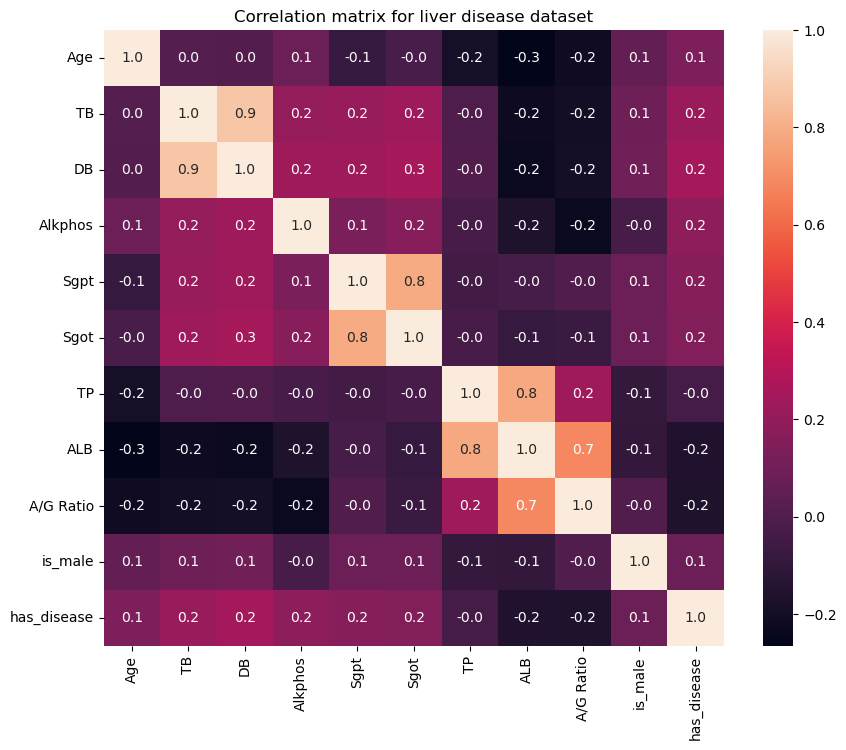

In [6]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot = True, fmt = '.1f')
plt.title('Correlation matrix for liver disease dataset')

In [7]:
# Shuffle the data to obtain random order for testing
df_shuff = df.sample(frac = 1, random_state = 42)

feature = df_shuff.drop('has_disease', axis = 1).to_numpy()
target = df_shuff['has_disease'].to_numpy()

# 80-20 train-test split
split_index = int(0.8 * 583)

f_train = feature[:split_index]
f_test = feature[split_index :]

mean = f_train.mean(axis = 0)
std = f_train.std(axis  = 0)

# Standardizing the data:
f_train = (f_train - mean) / std
# It is important to standardize test data with the same mean and std since in the real world, we wont know what mean and std of a new dataset will be beforehand 
f_test = (f_test - mean) / std 

f_train = np.c_[np.ones(f_train.shape[0]), f_train] # adding the intercept / bias column
f_test = np.c_[np.ones(f_test.shape[0]), f_test] 

t_train = target[:split_index]
t_test = target[split_index:]

In [8]:
theta = np.zeros(11) # Can be initialized to any value, 0 is convinient
epsilon = 1e-5 # For convergence

def gradient_ascent(f, t, thet):
    global epsilon
    while True:
        gradient = f.T @ (t - expit(f @ thet))
        theta_new = thet + 0.005 * gradient
        if np.linalg.norm(theta_new - thet) <= epsilon: # convergence condition
            return theta_new
        thet = theta_new.copy() 

In [9]:
theta_final = gradient_ascent(f_train, t_train, theta)

In [10]:
probabilities = expit(f_test @ theta_final)
predictions = (probabilities >= 0.5).astype(int)

accuracy = (predictions == t_test).astype(int)

In [11]:
print(f'Final value of theta: {theta_final}')
print(f'Accuracy of the model: {np.mean(accuracy) * 100 :.2f}%')

Final value of theta: [ 2.00840762  0.31652504 -0.71353139  2.24026827  0.2163617   1.90174986
  0.86681029  0.62745512 -0.77748267  0.36345174 -0.02223439]
Accuracy of the model: 75.21%


Since this is a health related study, it is necessary to calculate true negatives, true positives, false positives and false neagtives.

In [12]:
tp = np.sum((predictions == 1) & (t_test == 1))
tn = np.sum((predictions == 0) & (t_test == 0))
fp = np.sum((predictions == 1) & (t_test == 0))
fn = np.sum((predictions == 0) & (t_test == 1))

In [13]:
print(f"TP : {tp}")
print(f"TN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")

TP : 77
TN : 11
FP : 24
FN : 5


Sensitivity: $\dfrac{TP}{TP+FN} = 93.9\%$ 

Specificity: $\dfrac{TN}{TN+FP} = 31.4\%$ 

Precision: $\dfrac{TP}{TP+FP} = 76.2\%$


Text(58.22222222222221, 0.5, 'True Label')

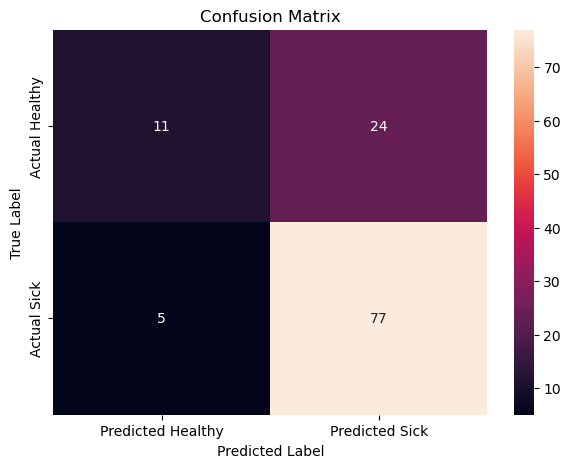

In [14]:
cm = np.array([[11, 24], # Confusion Matrix
               [5, 77]])

plt.figure(figsize = (7,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted Healthy', 'Predicted Sick'],
            yticklabels=['Actual Healthy', 'Actual Sick'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

---
# Summary

1. The model has decent accuracy of $75.21\%$. 
2. The Sensitivity, Specifity, and Precision values show that the model is highly accurate at catching the disease, it is paranoid (incorrectly diagnosed 24 out of 35 healthy patients), and a person is likely to be infected given that he/she has been labelled to be sick by the model, respectively. \
    2.1. Note that there is a bias in the data to having the disease, which makes the sensitivity score so high. \
    2.2. The model is safe because it rarely misses a sick patient, but it also over-diagnoses healthy ones. \
    2.3. From $\theta$ value, it is evident that `DB`, and `Sgpt` are the most significant features for the model.
---
## References
1. **Srivastava, S.** _Liver Patient Dataset._ Kaggle. Available at: https://www.kaggle.com/datasets/shauryasrivastava01/liver-patient-dataset